## 1. Import Required Libraries

# Pepper Robot IK Interactive Solver Test
This notebook tests the inverse kinematics controller for the Pepper robot. You can interactively change the arm positions using sliders and visualize the resulting joint angles.

In [40]:
import numpy as np
import os
import sys
import pandas as pd
from pathlib import Path

from ikpy.chain import Chain
from ikpy.utils import plot

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from ipywidgets import interact, FloatSlider, Output, VBox, HTML
import matplotlib.pyplot as plt

# Set up path to load chains
SCRIPT_DIR = Path('./pepper_ik_resources').resolve().parent
print(f"Working directory: {SCRIPT_DIR}")

Working directory: C:\Users\oscar\Documents\GitHub\Pepper-Imitation-System\01-server\dl-pose


## 2. Load Pepper Robot Chains

In [41]:
# Load the Pepper robot chains from JSON files
script_dir = os.path.dirname(os.path.abspath('.'))

pepper_left_arm_chain = Chain.from_json_file(os.path.join(script_dir, "dl-pose", "pepper_ik_resources",  "pepper_left_arm.json"))
pepper_right_arm_chain = Chain.from_json_file(os.path.join(script_dir, "dl-pose", "pepper_ik_resources", "pepper_right_arm.json"))
pepper_legs_chain = Chain.from_json_file(os.path.join(script_dir, "dl-pose", "pepper_ik_resources", "pepper_legs.json"))
pepper_head_chain = Chain.from_json_file(os.path.join(script_dir, "dl-pose", "pepper_ik_resources", "pepper_head.json"))

print("✓ Chains loaded successfully")
print(f"  Left arm joints: {len(pepper_left_arm_chain)}")
print(f"  Right arm joints: {len(pepper_right_arm_chain)}")
print(f"  Legs joints: {len(pepper_legs_chain)}")
print(f"  Head joints: {len(pepper_head_chain)}")

✓ Chains loaded successfully
  Left arm joints: 9
  Right arm joints: 9
  Legs joints: 7
  Head joints: 7


## 3. Visualize Robot Structure (Default Position)

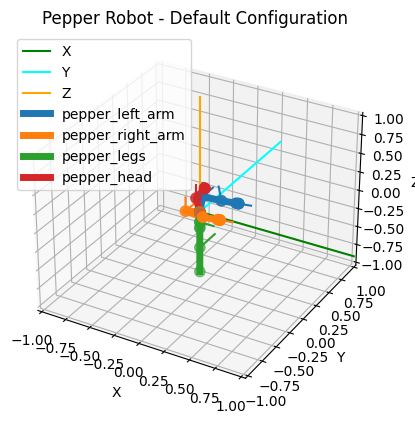

In [42]:
fig, ax = plot.init_3d_figure()
pepper_left_arm_chain.plot([0] * (len(pepper_left_arm_chain)), ax)
pepper_right_arm_chain.plot([0] * (len(pepper_right_arm_chain)), ax)
pepper_legs_chain.plot([0] * (len(pepper_legs_chain)), ax)
pepper_head_chain.plot([0] * (len(pepper_head_chain)), ax)
ax.legend()
plt.title("Pepper Robot - Default Configuration")
plt.show()

## 4. Interactive Inverse Kinematics Solver
Use the sliders below to move the left and right arm end-effectors. The IK solver will compute the required joint angles and display them.

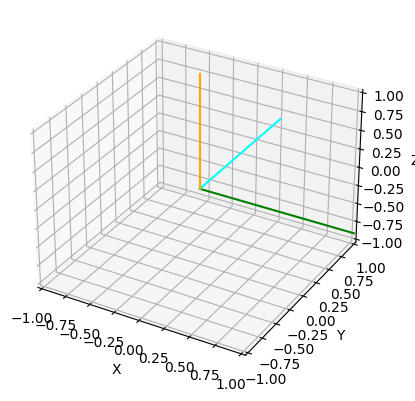

interactive(children=(FloatSlider(value=0.29704547692436817, description='Left X', max=30.297045476924367, min…

<function __main__.goto_fixed(xl, yl, zl, xr, yr, zr)>

In [ ]:
# Get initial position from forward kinematics
x2, y2, z2 = pepper_right_arm_chain.forward_kinematics([0] * (len(pepper_right_arm_chain)))[:3, 3]
size2 = 30

# Store angle history
angle_history_left2 = []
angle_history_right2 = []
position_history2 = []

# Create figure ONCE and reuse it
fig2, ax2 = plot.init_3d_figure()
xlim2 = ax2.get_xlim3d()
ylim2 = ax2.get_ylim3d()
zlim2 = ax2.get_zlim3d()

def goto_fixed(xl, yl, zl, xr, yr, zr):
    ax2.clear()
    
    # Right arm IK
    frame_target = np.eye(4)
    frame_target[:3, 3] = [xr, yr, zr]
    ik_right = pepper_right_arm_chain.inverse_kinematics_frame(frame_target, optimizer="scalar")
    pepper_right_arm_chain.plot(ik_right, ax2)
    
    # Left arm IK
    frame_target[:3, 3] = [xl, yl, zl]
    ik_left = pepper_left_arm_chain.inverse_kinematics_frame(frame_target, optimizer="scalar")
    pepper_left_arm_chain.plot(ik_left, ax2)
    
    # Plot legs and head
    pepper_legs_chain.plot([0] * (len(pepper_legs_chain)), ax2)
    pepper_head_chain.plot([0] * (len(pepper_head_chain)), ax2)
    
    # Manually plot target points without the 'target' parameter to avoid scatter plot conflict
    ax2.scatter([xl, xr], [yl, yr], [zl, zr], marker='x', s=200, c='red', linewidths=3, label='Targets')
    
    ax2.legend()
    ax2.set_xlabel('X (m)')
    ax2.set_ylabel('Y (m)')
    ax2.set_zlabel('Z (m)')
    
    # Store in history
    angle_history_left2.append(ik_left.copy())
    angle_history_right2.append(ik_right.copy())
    position_history2.append((xl, yl, zl, xr, yr, zr))
    
    # Print joint angles with names
    left_joint_names = [link.name for link in pepper_left_arm_chain.links[1:]]  # Skip base
    right_joint_names = [link.name for link in pepper_right_arm_chain.links[1:]]  # Skip base
    
    print("="*70)
    print(f"Target Position - Left: ({xl:.3f}, {yl:.3f}, {zl:.3f}), Right: ({xr:.3f}, {yr:.3f}, {zr:.3f})")
    print("-"*70)
    print("Left arm joint angles:")
    for i, (name, angle) in enumerate(zip(left_joint_names, ik_left)):
        print(f"  {name}: {angle:.4f} rad ({np.degrees(angle):.2f}°)")
    print("-"*70)
    print("Right arm joint angles:")
    for i, (name, angle) in enumerate(zip(right_joint_names, ik_right)):
        print(f"  {name}: {angle:.4f} rad ({np.degrees(angle):.2f}°)")
    print("="*70)
    
interact(goto_fixed,
         xl=FloatSlider(min=x2-size2, max=x2+size2, value=x2, step=0.01, description='Left X'),
         yl=FloatSlider(min=y2-size2, max=y2+size2, value=y2, step=0.01, description='Left Y'),
         zl=FloatSlider(min=z2-size2, max=z2+size2, value=z2, step=0.01, description='Left Z'),
         xr=FloatSlider(min=x2-size2, max=x2+size2, value=x2, step=0.01, description='Right X'),
         yr=FloatSlider(min=y2-size2, max=y2+size2, value=y2, step=0.01, description='Right Y'),
         zr=FloatSlider(min=z2-size2, max=z2+size2, value=z2, step=0.01, description='Right Z'))

## 5. Plot Joint Angles Over Position Changes
Track how joint angles change as you move the end-effectors through different positions.

📊 Plotting Joint Angle Statistics
✓ Data loaded from interactive sliders


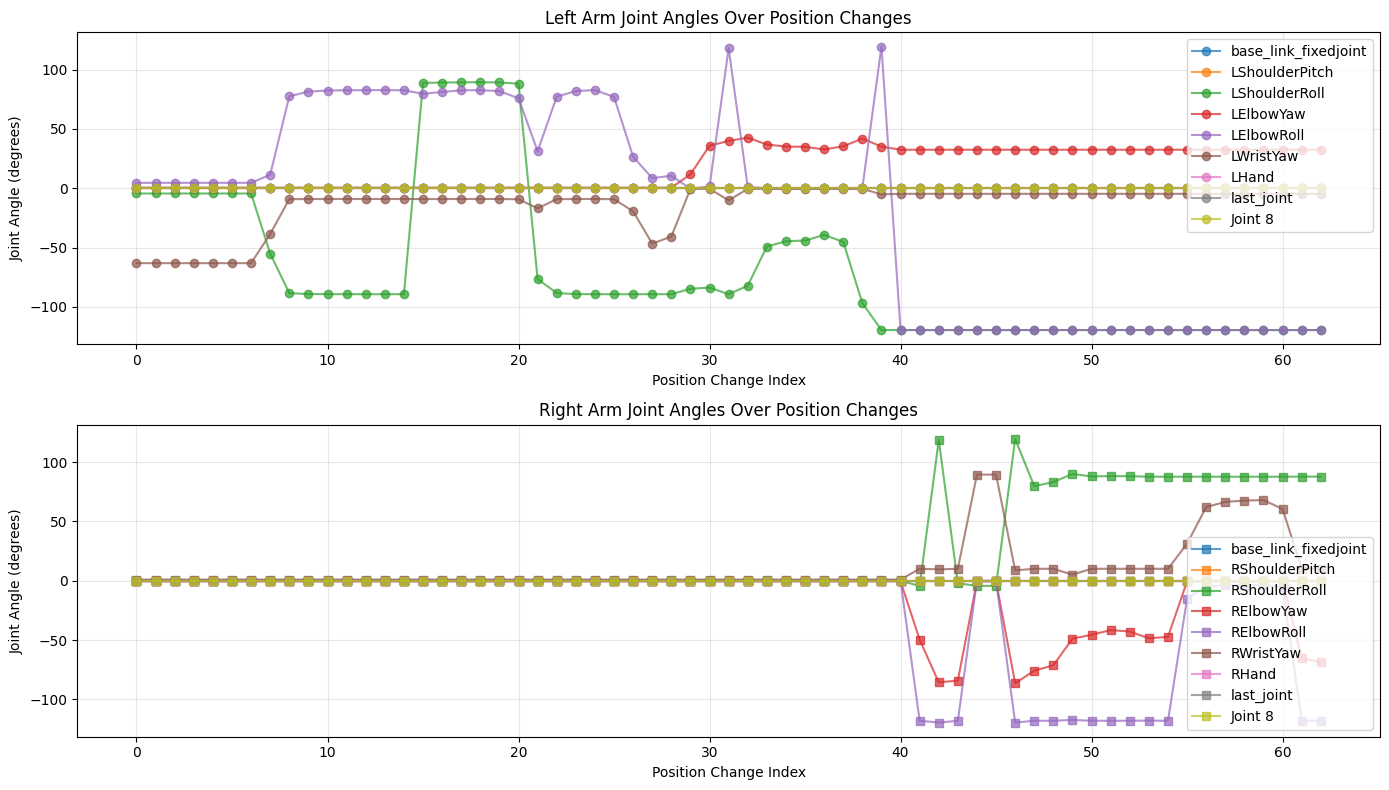


📊 Joint Angle Statistics

Left Arm:
  base_link_fixedjoint: min=0.00°, max=0.00°, mean=0.00°, std=0.00°
  LShoulderPitch: min=0.00°, max=0.00°, mean=0.00°, std=0.00°
  LShoulderRoll: min=-119.50°, max=89.36°, mean=-69.89°, std=63.12°
  LElbowYaw: min=0.50°, max=42.66°, mean=18.16°, std=16.66°
  LElbowRoll: min=-119.50°, max=119.50°, mean=-16.09°, std=84.87°
  LWristYaw: min=-63.13°, max=-0.50°, mean=-14.06°, std=19.30°
  LHand: min=0.00°, max=0.00°, mean=0.00°, std=0.00°
  last_joint: min=0.00°, max=0.00°, mean=0.00°, std=0.00°
  Joint 8: min=0.00°, max=0.00°, mean=0.00°, std=0.00°

Right Arm:
  base_link_fixedjoint: min=0.00°, max=0.00°, mean=0.00°, std=0.00°
  RShoulderPitch: min=0.00°, max=0.00°, mean=0.00°, std=0.00°
  RShoulderRoll: min=-4.37°, max=119.50°, mean=25.68°, std=41.51°
  RElbowYaw: min=-86.45°, max=-0.50°, mean=-14.06°, std=26.52°
  RElbowRoll: min=-119.50°, max=0.03°, mean=-26.83°, std=48.87°
  RWristYaw: min=1.01°, max=89.50°, mean=11.29°, std=22.35°
  RHand: min=0.

In [48]:
print("📊 Plotting Joint Angle Statistics")
print("="*70)

# Check if history has data
if len(angle_history_left2) > 0:
    angles_left = np.array(angle_history_left2)
    angles_right = np.array(angle_history_right2)
    print("✓ Data loaded from interactive sliders")
else:
    print("⚠️  No angle history recorded. Please use the interactive sliders above to collect data.")
    angles_left = None
    angles_right = None

if angles_left is not None and angles_right is not None:
    # Create plots for joint angle changes
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    # Left arm angles
    left_joint_names = [link.name for link in pepper_left_arm_chain.links[1:]]  # Skip base
    ax = axes[0]
    for i in range(angles_left.shape[1]):
        joint_name = left_joint_names[i] if i < len(left_joint_names) else f"Joint {i}"
        ax.plot(np.degrees(angles_left[:, i]), marker='o', label=joint_name, alpha=0.7)
    ax.set_title('Left Arm Joint Angles Over Position Changes')
    ax.set_xlabel('Position Change Index')
    ax.set_ylabel('Joint Angle (degrees)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Right arm angles
    right_joint_names = [link.name for link in pepper_right_arm_chain.links[1:]]  # Skip base
    ax = axes[1]
    for i in range(angles_right.shape[1]):
        joint_name = right_joint_names[i] if i < len(right_joint_names) else f"Joint {i}"
        ax.plot(np.degrees(angles_right[:, i]), marker='s', label=joint_name, alpha=0.7)
    ax.set_title('Right Arm Joint Angles Over Position Changes')
    ax.set_xlabel('Position Change Index')
    ax.set_ylabel('Joint Angle (degrees)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics with joint names
    left_joint_names = [link.name for link in pepper_left_arm_chain.links[1:]]  # Skip base
    right_joint_names = [link.name for link in pepper_right_arm_chain.links[1:]]  # Skip base
    
    print("\n📊 Joint Angle Statistics")
    print("="*70)
    print("\nLeft Arm:")
    for i in range(angles_left.shape[1]):
        angles_deg = np.degrees(angles_left[:, i])
        joint_name = left_joint_names[i] if i < len(left_joint_names) else f"Joint {i}"
        print(f"  {joint_name}: min={angles_deg.min():.2f}°, max={angles_deg.max():.2f}°, mean={angles_deg.mean():.2f}°, std={angles_deg.std():.2f}°")
    
    print("\nRight Arm:")
    for i in range(angles_right.shape[1]):
        angles_deg = np.degrees(angles_right[:, i])
        joint_name = right_joint_names[i] if i < len(right_joint_names) else f"Joint {i}"
        print(f"  {joint_name}: min={angles_deg.min():.2f}°, max={angles_deg.max():.2f}°, mean={angles_deg.mean():.2f}°, std={angles_deg.std():.2f}°")
